<a href="https://colab.research.google.com/github/ayesha-tubassum/fdlkdjg/blob/main/XG_BOOST(credit_card_fraud).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# **Step 1: Data Loading Steps**

In [3]:
df = pd.read_csv("/content/fraud_data.csv")

# **Step 2: Data understanding**

In [4]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [5]:
df.sample(10)

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
3100,26-12-2020 16:53,Kihn Inc,shopping_pos,5.40,Sutherland,NE,41.1558,-101.1360,1789,Insurance broker,11-02-1982,4b522342a77b0f099671f2167a0084c5,41.192716,-101.458746,0
6139,29-12-2020 16:11,"""Streich, Rolfson and Wilderman""",kids_pets,114.15,June Lake,CA,37.7773,-119.0825,633,Health service manager,09-09-1927,ef31cddac50cb255fae1198f5f47ded9,36.890665,-120.044144,0
3348,27-12-2020 00:05,Koss and Sons,gas_transport,53.30,Fields Landing,CA,40.7268,-124.2174,276,"""Scientist, audiological""",06-05-1929,dd4af6fe6e61a18cfc1fba9d1f37836d,41.534861,-124.493786,0
8497,03-01-2019 03:32,Koepp-Parke,grocery_pos,84.82,Shedd,OR,44.4530,-123.1065,917,Radio broadcast assistant,08-07-1995,30b8a119332238c230a82dfc3563cd0f,43.509941,-123.832092,0
10825,10-01-2019 15:59,Reichel LLC,personal_care,21.31,Rocky Mount,MO,38.2911,-92.7059,1847,Tax inspector,26-10-1988,294343492de28162024eedafb488c55c,38.418895,-93.119524,0
500,05-07-2019 20:04,Leffler-Goldne,personal_care,20.86,Jelm,WY,41.0539,-106.0763,100,Public librarian,16-04-1974,f47eb435c12df2eb1b0847508b57d78b,40.672427,-106.124137,1
2074,25-12-2020 02:53,Friesen-D'Amore,gas_transport,63.97,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,21-06-1978,9ac5f405c131cb12ff482f361f72e335,49.423538,-118.749525,0
535,27-07-2019 23:30,"""Douglas, Schneider and Turne""",shopping_pos,728.38,Manley,NE,40.9207,-96.1680,206,Human resources officer,04-10-1967,6c8378055fbef97cdd262927423980f1,41.832424,-96.456685,1
8033,01-01-2019 14:22,Lemke-Gutmann,shopping_net,3.49,Phoenix,AZ,33.5623,-112.0559,1312922,Contractor,24-10-1981,8ce31e2f24c96575cf55a89c830de3f2,33.866541,-112.505892,0
14084,21-01-2019 06:44,Huels-Hahn,gas_transport,57.48,Moriarty,NM,34.9889,-106.0609,7268,"""Therapist, art""",04-08-1988,14e4c826a8bf7da8eee871e93574dd9a,34.877347,-107.032380,0


In [6]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [7]:
df.shape

(14446, 15)

# **Step 3: Data Cleaning**

In [8]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  trans_num              14446 non-null  object 
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  object 
dtypes:

In [10]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long
count,14446.000000,14446.000000,14446.000000,1.444600e+04,14446.000000,14446.000000
mean,124.430073,39.787692,-110.874225,1.065370e+05,39.787991,-110.874892
std,231.352587,5.317039,12.985813,2.902916e+05,5.360593,12.995596
min,1.000000,20.027100,-165.672300,4.600000e+01,19.032689,-166.670685
25%,12.080000,36.715400,-120.415800,4.930000e+02,36.794655,-120.146253
50%,51.520000,39.666200,-111.098500,1.645000e+03,39.620953,-111.192629
75%,101.030000,41.940400,-101.136000,3.543900e+04,42.275740,-100.446822
max,3261.470000,66.693300,-89.628700,2.383912e+06,67.510267,-88.646366


In [11]:
print(df['is_fraud'].value_counts())

is_fraud
0                         12600
1                          1844
1"2020-12-24 16:56:24"        1
0"2019-01-01 00:00:44"        1
Name: count, dtype: int64


In [12]:
df = df.drop([
    'trans_num',
    'trans_date_trans_time'
], axis=1)

In [13]:
# Convert dob column into datetime
df['dob'] = pd.to_datetime(df['dob'], dayfirst=True)
current_year = 2026
df['age'] = current_year - df['dob'].dt.year
df = df.drop('dob', axis=1)

In [20]:
print(df['is_fraud'].unique())

['1' '1"2020-12-24 16:56:24"' '0' '0"2019-01-01 00:00:44"']


In [22]:
df['is_fraud'] = df['is_fraud'].astype(str)

In [23]:
df['is_fraud'] = df['is_fraud'].str.extract('(0|1)')

In [24]:
df = df.dropna(subset=['is_fraud'])

In [25]:
df['is_fraud'] = df['is_fraud'].astype(int)

In [26]:
print(df['is_fraud'].unique())

[1 0]


# **Step 4: Feature Engineering**

In [30]:
le = LabelEncoder()
categorical_cols = ['merchant', 'category', 'city', 'state', 'job']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [31]:
df.shape

(14446, 13)

# **Step 5: Train Test Split**

In [37]:

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Step 6: Model Selection and Model Training**

In [43]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

In [44]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
df['is_fraud'] = df['is_fraud'].astype(int)

# **Step 7: Model Prediction**

In [45]:
y_pred = model.predict(X_test)

# **Step 8: Model Evaluation**

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9782006920415225


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2505
           1       0.95      0.88      0.91       385

    accuracy                           0.98      2890
   macro avg       0.97      0.94      0.95      2890
weighted avg       0.98      0.98      0.98      2890



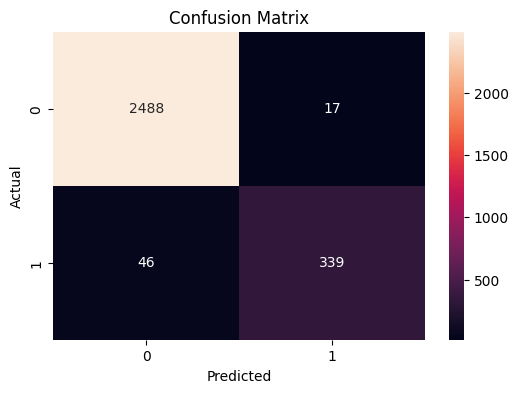

In [48]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
importance = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print(feature_df)

       Feature  Importance
2          amt    0.502741
1     category    0.179986
11         age    0.054164
4        state    0.036379
7     city_pop    0.033689
8          job    0.032674
5          lat    0.030906
3         city    0.029110
10  merch_long    0.028235
6         long    0.027546
9    merch_lat    0.022629
0     merchant    0.021940


# **Step 9: Model Tuning (Hyperparameter Tuning)**

In [51]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best Accuracy: 0.9737798546209762


# **Step 10: Cross Validation**

In [53]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5
)
print("Cross Validation Scores:")
print(scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores:
[0.96782007 0.9633091  0.97161648 0.95742471 0.97300104]
Average Accuracy: 0.9666342803690409


# **Step 11: Pipeline Building**

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.975432525951557
